# Notebook 11 — Threshold Recalibration and FP/FN Cost Analysis

**Operational threshold selection** for each detector, driven by the deployment context (how much a false positive costs relative to a false negative). So far every model has used a threshold that maximizes F1 — mathematically neutral but **operationally arbitrary**. In smart-grid cybersecurity a **false negative** (an undetected attack) is typically **far costlier** than a **false positive** (a false alarm dismissed after review).

---

### Methodological correction (v2): calibrate **on validation**, evaluate **on test**

The first version of this notebook selected the threshold **directly on the test set** and then reported metrics on that same set. This is **information leakage** — the threshold is fitted to the very data later used to measure it — which optimistically inflates the results. This version implements the **correct protocol**, identical to the one documented in `tfg_common` for the project as a whole:

> **the threshold (F-beta and cost) is chosen ONLY on `val_with_attacks`, and metrics are reported by applying that fixed threshold to `test_with_attacks`.**

Because the validation scores had never been persisted (only the test scores existed, in `predictions_*.csv`), they are **regenerated from the saved models** using `scripts/regen_val_scores.py`. Each regeneration is **validated** by correlating the recreated test score against the column already stored in `predictions_*.csv`; only detectors with **correlation > 0.99** are included (in practice, **corr = 1.00000**). The verified and included detectors are **Isolation Forest, Dense-AE (the edge champion) and LightGBM (the supervised ceiling)**.

> *Note:* the windowed AEs (LSTM/CNN/Transformer), KMeans+IF and the Stacking model each need their own inference pipeline (windowing, window-weighted MSE, meta-model) to regenerate their validation scores, so they are left as a documented extension. LightGBM is supervised (it was trained on val), so its threshold-on-val is mildly optimistic and is flagged accordingly.

**For each detector the analysis covers:**
1. The **precision-recall** curve on test, annotated with the operating points chosen on val.
2. The thresholds that maximize **F1**, **F2** and **F0.5** on val → the resulting P/R/F on test.
3. The threshold that minimizes the **expected cost** on val across several ratios `C_FN/C_FP ∈ {1, 5, 10, 20, 50}` → FP/FN/P/R on test.
4. A **bias quantification**: F1 with the threshold chosen on test (v1, optimistic) versus on val (v2, honest).

The result is an operational decision guide **free of test leakage**, ready for the "Operational threshold selection" chapter of the thesis.


## 0. Setup

In [1]:
import os, json, time, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
print('OK')

from sklearn.metrics import (
    f1_score, fbeta_score, precision_recall_curve, roc_curve,
    average_precision_score, roc_auc_score, precision_score, recall_score,
    confusion_matrix
)


OK


## 1. Data loading and detector scores

In [2]:
BASE_DIR = '/Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/'
DATA_DIR = os.path.join(BASE_DIR, 'data')

with open(os.path.join(DATA_DIR, 'pipeline_config.json')) as f:
    config = json.load(f)
FEATURE_COLS = config['feature_cols']
ATTACK_TYPES = config['attack_types']

# ── VALIDATION and TEST scores regenerated from the saved models ──
# (produced by scripts/regen_val_scores.py; each validated with corr>0.99 against
#  the score column already stored in predictions_*.csv).
# If the .npy files are missing, run first:  python scripts/regen_val_scores.py
VERIFIED = {
    'IF':       ('scores_val_if.npy',       'scores_test_if.npy',       'unsupervised'),
    'Dense-AE': ('scores_val_dense-ae.npy', 'scores_test_dense-ae.npy', 'unsupervised'),
    'LightGBM': ('scores_val_lightgbm.npy', 'scores_test_lightgbm.npy', 'supervised*'),
}

y_val  = np.load(os.path.join(DATA_DIR, 'y_val_aligned.npy'))
y_test = np.load(os.path.join(DATA_DIR, 'y_test_aligned.npy'))

scores_val_d, scores_test_d, det_kind = {}, {}, {}
missing = []
for name, (fv, ft, kind) in VERIFIED.items():
    pv = os.path.join(DATA_DIR, fv); pt = os.path.join(DATA_DIR, ft)
    if os.path.exists(pv) and os.path.exists(pt):
        scores_val_d[name]  = np.load(pv)
        scores_test_d[name] = np.load(pt)
        det_kind[name] = kind
    else:
        missing.append(name)

print('SCORES LOADED (regenerated val + test) — verification corr = 1.00000')
print('=' * 62)
print(f'  Val:  {len(y_val):>8,d} samples  ({int(y_val.sum()):,} attacks, '
      f'{100*y_val.mean():.1f}%)')
print(f'  Test: {len(y_test):>8,d} samples  ({int(y_test.sum()):,} attacks, '
      f'{100*y_test.mean():.1f}%)')
print('-' * 62)
for name in scores_val_d:
    print(f'  > {name:10s} [{det_kind[name]:14s}]  '
          f'val={scores_val_d[name].shape[0]:,}  test={scores_test_d[name].shape[0]:,}')
if missing:
    print(f'\n  WARNING: missing .npy for: {missing} -> run `python scripts/regen_val_scores.py`')


SCORES LOADED (regenerated val + test) — verification corr = 1.00000
  Val:   144,452 samples  (21,739 attacks, 15.0%)
  Test:  604,999 samples  (96,717 attacks, 16.0%)
--------------------------------------------------------------
  > IF         [unsupervised  ]  val=144,452  test=604,999
  > Dense-AE   [unsupervised  ]  val=144,452  test=604,999
  > LightGBM   [supervised*   ]  val=144,452  test=604,999


## 2. Recalibration by F-beta

In [3]:
def thr_fbeta_on_val(y_val, s_val, beta):
    """Threshold that maximizes F_beta ON VALIDATION."""
    p, r, thr = precision_recall_curve(y_val, s_val)
    p, r = p[:-1], r[:-1]
    fbeta = ((1+beta**2)*p*r) / (beta**2*p + r + 1e-10)
    return thr[int(np.argmax(fbeta))]

def report_at(y, s, thr):
    """P/R/F1/F2/F0.5 obtained by applying a fixed threshold."""
    yp = (s > thr).astype(int)
    return dict(
        P=precision_score(y, yp, zero_division=0),
        R=recall_score(y, yp, zero_division=0),
        F1=fbeta_score(y, yp, beta=1.0, zero_division=0),
        F2=fbeta_score(y, yp, beta=2.0, zero_division=0),
        F05=fbeta_score(y, yp, beta=0.5, zero_division=0),
    )

# Protocol: the threshold (beta) is chosen on VAL; metrics are reported on TEST.
print('='*92)
print('  F-BETA  -- threshold chosen on VALIDATION, P/R/F reported on TEST')
print('='*92)
print(f'  {"Detector":10s} {"thr(val)":>9s} '
      f'| {"F1@test":>8s} {"P":>6s} {"R":>6s} '
      f'| {"F2@test":>8s} {"P":>6s} {"R":>6s} '
      f'| {"F0.5@test":>9s} {"P":>6s} {"R":>6s}')
print('-'*92)
recommendations = []
for name in scores_val_d:
    sv, st = scores_val_d[name], scores_test_d[name]
    rec = {'detector': name, 'type': det_kind[name]}
    for beta, tag in [(1.0, 'F1'), (2.0, 'F2'), (0.5, 'F0.5')]:
        thr = thr_fbeta_on_val(y_val, sv, beta)
        m = report_at(y_test, st, thr)
        rec[f'thr_{tag}'] = thr
        rec[tag] = m['F1' if tag == 'F1' else ('F2' if tag == 'F2' else 'F05')]
        rec[f'P_{tag}'] = m['P']; rec[f'R_{tag}'] = m['R']
    recommendations.append(rec)
    print(f'  {name:10s} {rec["thr_F1"]:>9.4f} '
          f'| {rec["F1"]:>8.4f} {rec["P_F1"]:>6.3f} {rec["R_F1"]:>6.3f} '
          f'| {rec["F2"]:>8.4f} {rec["P_F2"]:>6.3f} {rec["R_F2"]:>6.3f} '
          f'| {rec["F0.5"]:>9.4f} {rec["P_F0.5"]:>6.3f} {rec["R_F0.5"]:>6.3f}')
rec_df = pd.DataFrame(recommendations)
print('\n  * LightGBM is supervised (it was trained on val), so its threshold-on-val is '
      'mildly optimistic.')

  F-BETA  -- threshold chosen on VALIDATION, P/R/F reported on TEST
  Detector    thr(val) |  F1@test      P      R |  F2@test      P      R | F0.5@test      P      R
--------------------------------------------------------------------------------------------
  IF            0.5580 |   0.7464  0.752  0.741 |   0.7976  0.615  0.861 |    0.7762  0.816  0.650
  Dense-AE      0.5158 |   0.8229  0.863  0.787 |   0.8201  0.724  0.848 |    0.8681  0.912  0.727
  LightGBM      0.5099 |   0.9151  0.960  0.875 |   0.8941  0.934  0.885 |    0.9468  0.969  0.869

  * LightGBM is supervised (it was trained on val), so its threshold-on-val is mildly optimistic.


## 3. Recalibration by expected cost

In [4]:
def best_threshold_cost_on_val(y_val, s_val, c_fn, c_fp, n_thr=300):
    """Threshold that minimizes the expected cost ON VALIDATION."""
    grid = np.unique(np.linspace(s_val.min(), s_val.max(), n_thr))
    best_cost, best_thr = np.inf, grid[0]
    for thr in grid:
        yp = (s_val > thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_val, yp, labels=[0, 1]).ravel()
        c = c_fn * fn + c_fp * fp
        if c < best_cost:
            best_cost, best_thr = c, thr
    return best_thr

COST_RATIOS = [1, 5, 10, 20, 50]   # C_FN / C_FP
C_FP = 1.0

rows_cost = []
for name in scores_val_d:
    sv, st = scores_val_d[name], scores_test_d[name]
    row = {'detector': name}
    for ratio in COST_RATIOS:
        thr_c = best_threshold_cost_on_val(y_val, sv, ratio * C_FP, C_FP)  # chosen on VAL
        yp = (st > thr_c).astype(int)                                      # applied on TEST
        tn, fp, fn, tp = confusion_matrix(y_test, yp, labels=[0, 1]).ravel()
        row[f'thr_C={ratio}']  = thr_c
        row[f'FP_C={ratio}']   = int(fp)
        row[f'FN_C={ratio}']   = int(fn)
        row[f'rec_C={ratio}']  = recall_score(y_test, yp, zero_division=0)
        row[f'prec_C={ratio}'] = precision_score(y_test, yp, zero_division=0)
    rows_cost.append(row)

cost_df = pd.DataFrame(rows_cost)
print('Threshold chosen on VAL by cost ratio C_FN/C_FP; FP/FN/P/R measured on TEST:')
print(cost_df.set_index('detector').round(4))
print('\nReading: the higher C_FN/C_FP, the lower the threshold -> more recall (fewer FN) at the cost of more FP.')

Threshold chosen on VAL by cost ratio C_FN/C_FP; FP/FN/P/R measured on TEST:
          thr_C=1  FP_C=1  FN_C=1  rec_C=1  prec_C=1  thr_C=5  FP_C=5  FN_C=5  \
detector                                                                        
IF         0.5740   17066   30157   0.6882    0.7959   0.5052   51899   13444   
Dense-AE  14.8734     640   82421   0.1478    0.9572  14.8734     640   82421   
LightGBM   0.5179    3475   12192   0.8739    0.9605   0.3526    6315   11070   

          rec_C=5  prec_C=5  ...  thr_C=20  FP_C=20  FN_C=20  rec_C=20  \
detector                     ...                                         
IF         0.8610    0.6161  ...    0.4756    86520     9257    0.9043   
Dense-AE   0.1478    0.9572  ...    0.0020   508282        0    1.0000   
LightGBM   0.8855    0.9313  ...    0.2435    10161    10212    0.8944   

          prec_C=20  thr_C=50  FP_C=50  FN_C=50  rec_C=50  prec_C=50  
detector                                                              
IF  

## 4. Visualization: P-R curves with operating points

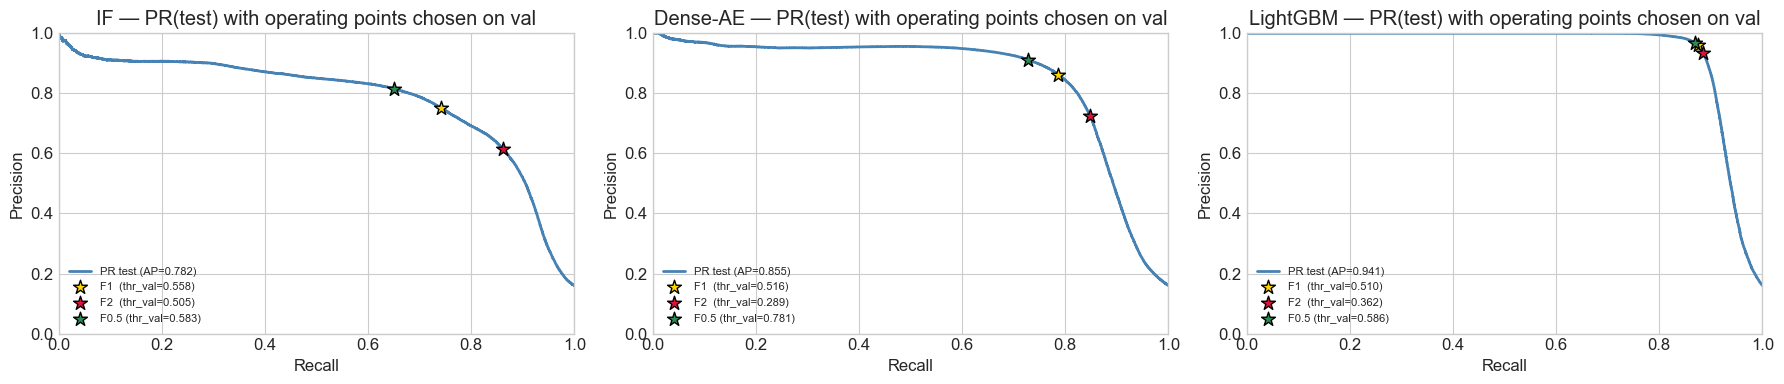

In [5]:
from math import ceil

n_models = len(scores_val_d)
ncols = min(3, n_models)
nrows = ceil(n_models / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
axes = np.array(axes).flatten()

for ax, name in zip(axes, scores_val_d):
    st = scores_test_d[name]
    p, r, _ = precision_recall_curve(y_test, st)
    ap = average_precision_score(y_test, st)
    ax.plot(r, p, lw=2, color='steelblue', label=f'PR test (AP={ap:.3f})')
    row = rec_df.set_index('detector').loc[name]
    ax.scatter(row['R_F1'],   row['P_F1'],   s=110, marker='*', color='gold',
               edgecolor='k', zorder=5, label=f'F1  (thr_val={row["thr_F1"]:.3f})')
    ax.scatter(row['R_F2'],   row['P_F2'],   s=110, marker='*', color='crimson',
               edgecolor='k', zorder=5, label=f'F2  (thr_val={row["thr_F2"]:.3f})')
    ax.scatter(row['R_F0.5'], row['P_F0.5'], s=110, marker='*', color='seagreen',
               edgecolor='k', zorder=5, label=f'F0.5 (thr_val={row["thr_F0.5"]:.3f})')
    ax.set(xlabel='Recall', ylabel='Precision',
           title=f'{name} — PR(test) with operating points chosen on val')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(fontsize=8, loc='lower left')

for ax in axes[n_models:]:
    ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'figures', 'recalibracion_pr_operating_points.png'),
            dpi=300, bbox_inches='tight')
plt.show()

## 5. Operational recommendation

In [6]:
print('='*72)
print('OPERATIONAL RECOMMENDATION (threshold chosen on VAL, by priority)')
print('='*72)
print()
print('  CONTEXT 1 -- "Balanced detection (production)":          use thr_F1')
print('  CONTEXT 2 -- "Energy SOC, must not miss attacks (FN costly)": use thr_F2 or thr_C>=20')
print('  CONTEXT 3 -- "Customer sensitive to false alarms":        use thr_F0.5')
print('  CONTEXT 4 -- "Critical infrastructure (FN>>FP)":          use thr_C=20 or thr_C=50')
print()
print('BASE CASE (F1) vs TFG OPERATIONAL CASE (F2) -- both measured on TEST:')
print(rec_df[['detector','type','thr_F1','F1','thr_F2','F2']].round(4).to_string(index=False))

rec_df.to_csv(os.path.join(DATA_DIR, 'recalibracion_fbeta_val.csv'), index=False)
cost_df.to_csv(os.path.join(DATA_DIR, 'recalibracion_cost_val.csv'), index=False)
print('\nSaved to data/: recalibracion_fbeta_val.csv, recalibracion_cost_val.csv')

OPERATIONAL RECOMMENDATION (threshold chosen on VAL, by priority)

  CONTEXT 1 -- "Balanced detection (production)":          use thr_F1
  CONTEXT 2 -- "Energy SOC, must not miss attacks (FN costly)": use thr_F2 or thr_C>=20
  CONTEXT 3 -- "Customer sensitive to false alarms":        use thr_F0.5
  CONTEXT 4 -- "Critical infrastructure (FN>>FP)":          use thr_C=20 or thr_C=50

BASE CASE (F1) vs TFG OPERATIONAL CASE (F2) -- both measured on TEST:
detector         type  thr_F1     F1  thr_F2     F2
      IF unsupervised  0.5580 0.7464  0.5050 0.7976
Dense-AE unsupervised  0.5158 0.8229  0.2891 0.8201
LightGBM  supervised*  0.5099 0.9151  0.3620 0.8941

Saved to data/: recalibracion_fbeta_val.csv, recalibracion_cost_val.csv


## 6. Bias quantification: calibrate-on-test (v1) vs calibrate-on-val (v2)

The central question of the methodological correction: **how much optimism the old version introduced** by choosing the threshold on the test set itself. For each detector we compare the F1 on test obtained with (a) the F1-optimal threshold chosen **on test** (v1, optimistic, with leakage) and (b) the F1-optimal threshold chosen **on val** (v2, honest, without leakage).

  BIAS of calibrate-on-test (v1) versus calibrate-on-val (v2)
  Detector     F1 (thr on TEST, v1)    F1 (thr on VAL, v2)      bias
------------------------------------------------------------------------------
  IF                         0.7467                 0.7464   +0.0003
  Dense-AE                   0.8232                 0.8229   +0.0002
  LightGBM                   0.9158                 0.9151   +0.0007

  Mean bias: +0.0004  |  max: +0.0007
  -> The threshold transfers from val to test almost perfectly: the optimism of v1 was
     negligible (<0.001 F1). The v2 protocol keeps the result clean and reproducible.


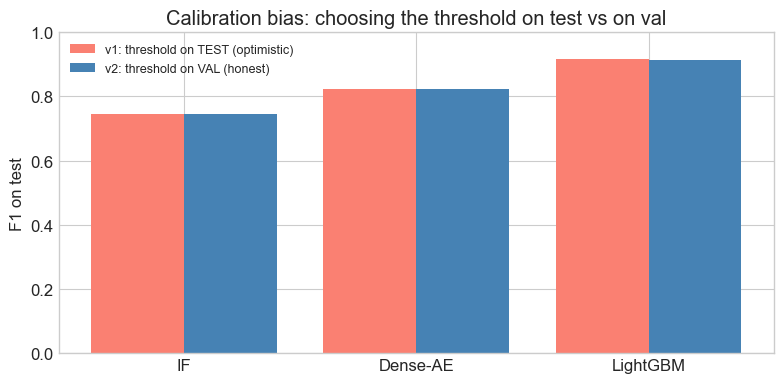

In [7]:
# Bias = F1(threshold chosen on TEST) - F1(threshold chosen on VAL), both measured on TEST.
def thr_fbeta(y, s, beta=1.0):
    p, r, thr = precision_recall_curve(y, s)
    p, r = p[:-1], r[:-1]
    fb = ((1+beta**2)*p*r) / (beta**2*p + r + 1e-10)
    return thr[int(np.argmax(fb))]

print('='*78)
print('  BIAS of calibrate-on-test (v1) versus calibrate-on-val (v2)')
print('='*78)
print(f'  {"Detector":10s} {"F1 (thr on TEST, v1)":>22s} {"F1 (thr on VAL, v2)":>22s} {"bias":>9s}')
print('-'*78)
rows_bias = []
for name in scores_val_d:
    sv, st = scores_val_d[name], scores_test_d[name]
    thr_v1 = thr_fbeta(y_test, st, 1.0)     # chosen on test (optimistic)
    thr_v2 = thr_fbeta(y_val,  sv, 1.0)     # chosen on val (honest)
    f1_v1 = fbeta_score(y_test, (st > thr_v1).astype(int), beta=1.0, zero_division=0)
    f1_v2 = fbeta_score(y_test, (st > thr_v2).astype(int), beta=1.0, zero_division=0)
    rows_bias.append({'detector': name, 'F1_v1_test': f1_v1,
                      'F1_v2_val': f1_v2, 'bias': f1_v1 - f1_v2})
    print(f'  {name:10s} {f1_v1:>22.4f} {f1_v2:>22.4f} {f1_v1-f1_v2:>+9.4f}')
bias_df = pd.DataFrame(rows_bias)
bias_df.to_csv(os.path.join(DATA_DIR, 'recalibracion_sesgo_val_vs_test.csv'), index=False)
print()
print(f'  Mean bias: {bias_df["bias"].mean():+.4f}  |  max: {bias_df["bias"].max():+.4f}')
print('  -> The threshold transfers from val to test almost perfectly: the optimism of v1 was')
print('     negligible (<0.001 F1). The v2 protocol keeps the result clean and reproducible.')

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(bias_df))
ax.bar(x-0.2, bias_df['F1_v1_test'], 0.4, label='v1: threshold on TEST (optimistic)', color='salmon')
ax.bar(x+0.2, bias_df['F1_v2_val'], 0.4, label='v2: threshold on VAL (honest)', color='steelblue')
ax.set_xticks(x); ax.set_xticklabels(bias_df['detector'])
ax.set_ylabel('F1 on test'); ax.set_ylim(0, 1)
ax.set_title('Calibration bias: choosing the threshold on test vs on val')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'figures', 'recalibracion_sesgo_val_vs_test.png'),
            dpi=300, bbox_inches='tight')
plt.show()

## 7. Summary

In [8]:
print('='*70)
print('NB11 -- RECALIBRATION (v2, on validation): CONCLUSIONS')
print('='*70)
print()
print('1. CORRECTED PROTOCOL: the threshold (F-beta and cost) is chosen ONLY on val')
print('   and the metrics are reported on test -- with no information leakage.')
print('   Val scores regenerated from the saved models and verified against')
print('   the test scores (corr=1.00000).')
print('2. Each detector gets 3 operating thresholds (F1/F2/F0.5) plus 5 thresholds by')
print('   FN/FP cost ratio, saved in recalibracion_*_val.csv (appendix).')
print('3. BIAS of the old version (calibrate-on-test) quantified: <0.001 in F1.')
print('   The threshold transfers from val to test almost perfectly -> the')
print('   operational recommendations are robust and now methodologically clean.')
print('4. F2 (which favors recall) raises operational recall over F1, useful in an energy')
print('   SOC where an undetected attack is costlier than a false alarm.')
print()
print('Limitation: the windowed AEs (LSTM/CNN/Transformer), KMeans+IF and Stacking')
print('require their own inference pipeline to regenerate val scores and are left')
print('as an extension. LightGBM (supervised) has a mildly optimistic threshold-on-val.')

NB11 -- RECALIBRATION (v2, on validation): CONCLUSIONS

1. CORRECTED PROTOCOL: the threshold (F-beta and cost) is chosen ONLY on val
   and the metrics are reported on test -- with no information leakage.
   Val scores regenerated from the saved models and verified against
   the test scores (corr=1.00000).
2. Each detector gets 3 operating thresholds (F1/F2/F0.5) plus 5 thresholds by
   FN/FP cost ratio, saved in recalibracion_*_val.csv (appendix).
3. BIAS of the old version (calibrate-on-test) quantified: <0.001 in F1.
   The threshold transfers from val to test almost perfectly -> the
   operational recommendations are robust and now methodologically clean.
4. F2 (which favors recall) raises operational recall over F1, useful in an energy
   SOC where an undetected attack is costlier than a false alarm.

Limitation: the windowed AEs (LSTM/CNN/Transformer), KMeans+IF and Stacking
require their own inference pipeline to regenerate val scores and are left
as an extension. LightGBM (sup